# Medical Insurance Charges Prediction Model using ML

---
## Load Dataset & Insights of Dataset

In [67]:
import pandas as pd

df = pd.read_csv("Insurance Dataset.csv")
df.head() # 1st 5 rows of the dataset

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0,yes,southwest,16884.92400
1,18.0,male,33.770,1,no,southeast,1725.55230
2,28.0,male,33.000,3,no,southeast,4449.46200
3,33.0,male,22.705,0,no,northwest,21984.47061
4,32.0,male,28.880,0,no,northwest,3866.85520


In [68]:
df.info() # Check structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1305 non-null   float64
 1   sex       1338 non-null   object 
 2   bmi       1305 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 73.3+ KB


There are missing values in # Age and # BMI columns which are needed to be handled

In [69]:
df.describe() # Statistical Summary

,age,bmi,children,charges
count,1305.000000,1305.000000,1338.000000,1338.000000
mean,39.215326,30.652621,1.094918,13270.422265
std,14.081612,6.110874,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4740.287150
50%,39.000000,30.305000,1.000000,9382.033000
75%,51.000000,34.700000,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


• The dataset contains both numerical and categorical features. 

• Numerical features include age, BMI, and charges, while categorical features include sex, smoker status, and region.

---
## Cleaning Data and Handle Missing Values

In [70]:
df.isnull().sum()

age         33
sex          0
bmi         33
children     0
smoker       0
region       0
charges      0
dtype: int64

Missing values are there in Age and Bmi columns which are numerical columns.

### To Handle missing values - " MEDIAN IMPUTATION METHOD " was used to avoid the influence of potential outliers.

In [71]:
df['age'] = df['age'].fillna(df['age'].median())

In [72]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [73]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [74]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows found: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates()

Duplicate rows found: 1


---
## Data Analysis (EDA) & Data Visualization

In [75]:
df.shape
df.columns
df.info()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   float64
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 83.6+ KB


np.int64(0)

In [76]:
for col in ['sex', 'smoker', 'region']:
    print(f"{col}: {df[col].unique()}")

sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

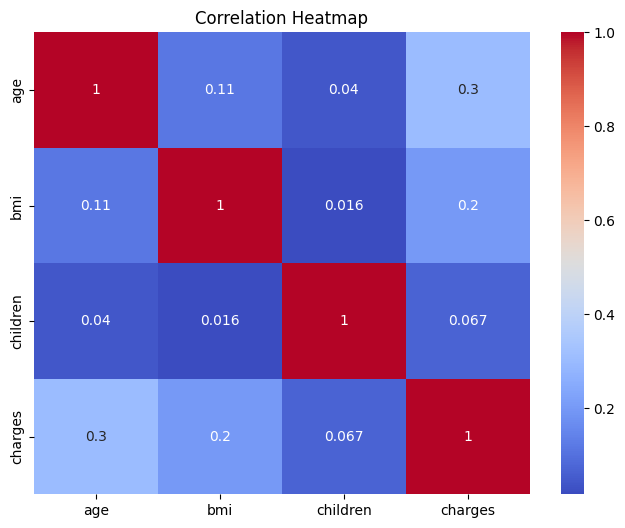

In [78]:
# CORRELATION USING HEATMAP 
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

• The correlation heatmap shows that age has the strongest positive relationship with medical charges, followed by BMI.

• This tells Patient Age and Health condition(BMI) plays key  role in Medical expenses

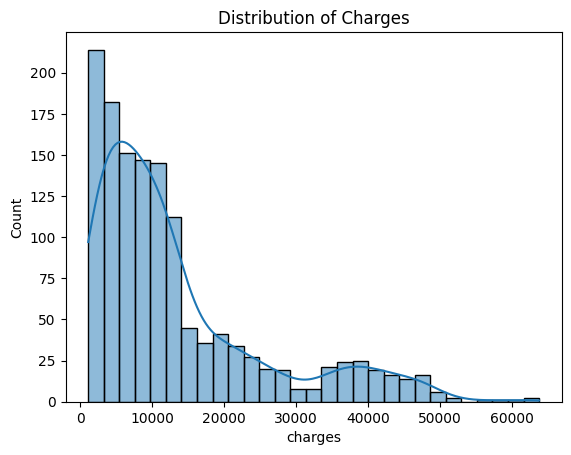

In [79]:
# Analysis of CHARGES
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Charges")
plt.show()

• Medical charges are highly right-skewed, which means Most people have low charges, few have very high charges.

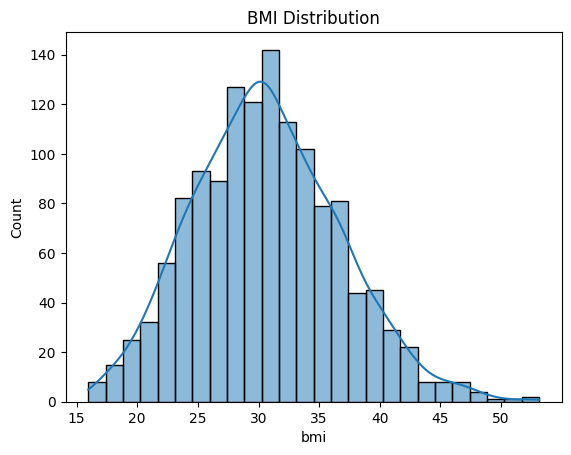

In [80]:
# Analysis of BMI
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

• BMI is normally distributed with slight skewness, indicating most patients fall within a common range, supporting the use of median imputation.

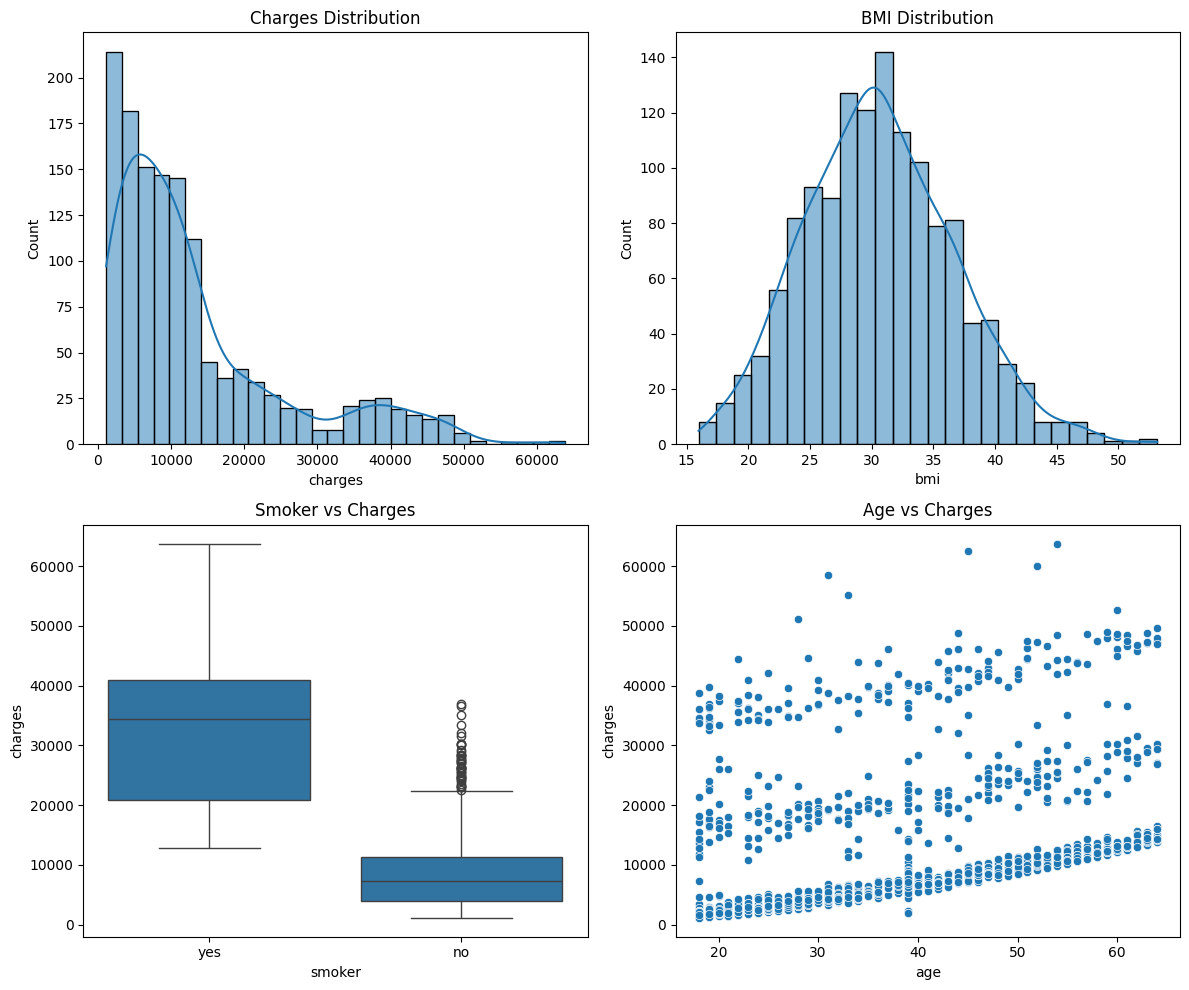

In [81]:
plt.figure(figsize=(12,10))

# Plot 1: Charges Distribution
plt.subplot(2,2,1)
sns.histplot(df['charges'], kde=True)
plt.title("Charges Distribution")

# Plot 2: BMI Distribution
plt.subplot(2,2,2)
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")

# Plot 3: Smoker vs Charges
plt.subplot(2,2,3)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")

# Plot 4: Age vs Charges
plt.subplot(2,2,4)
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")

plt.tight_layout()
plt.show()

### Smokers vs Charges analysis

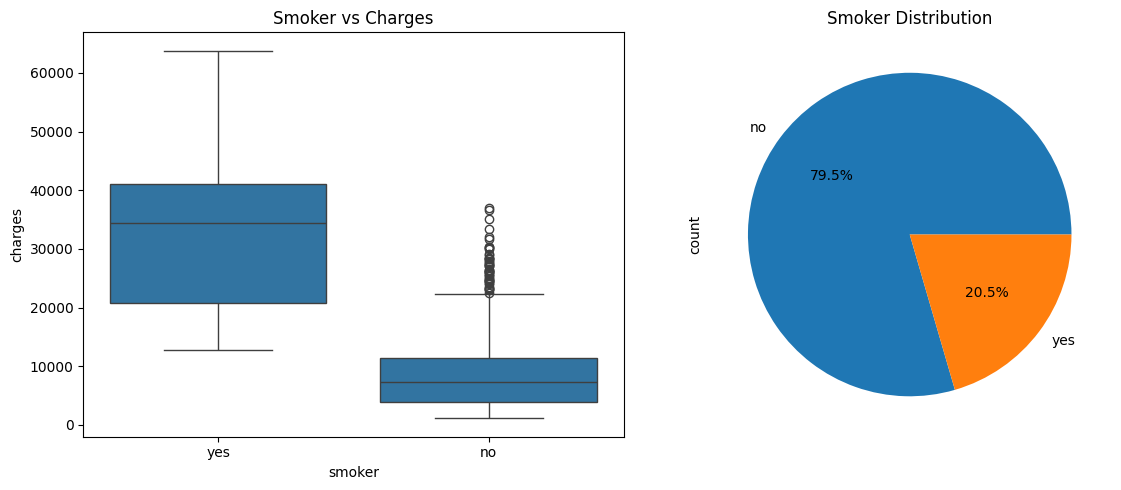

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

#  Boxplot
plt.subplot(1,2,1)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")

#  Pie Chart
plt.subplot(1,2,2)
df['smoker'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Smoker Distribution")

plt.tight_layout()
plt.show()

In [83]:
smoker_avg = df.groupby('smoker')['charges'].mean()

print("Smoker Avg Charges:", round(smoker_avg['yes'], 0))
print("Non-Smoker Avg Charges:", round(smoker_avg['no'], 0))

Smoker Avg Charges: 32050.0
Non-Smoker Avg Charges: 8441.0


---
## Feature Engineering & Preprocessing

In [84]:
## ENCODING
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_model = df.copy() # Copy of cleaned data frame

# Encode categorical variables
# For Binary columns: Label Encoding
df_model['sex'] = LabelEncoder().fit_transform(df_model['sex'])          # male=1, female=0
df_model['smoker'] = LabelEncoder().fit_transform(df_model['smoker'])    # yes=1, no=0

# For Multi-class: One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

print('Encoded Dataset Columns:')
print(df_model.columns.tolist())
print(f'\nDataset shape after encoding: {df_model.shape}')
df_model.head()

Encoded Dataset Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Dataset shape after encoding: (1337, 9)


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19.0,0,27.900,0,1,16884.92400,False,False,True
1,18.0,1,33.770,1,0,1725.55230,False,True,False
2,28.0,1,33.000,3,0,4449.46200,False,True,False
3,33.0,1,22.705,0,0,21984.47061,True,False,False
4,32.0,1,28.880,0,0,3866.85520,True,False,False


In [85]:
# Feature-Target Split 
X = df_model.drop('charges', axis=1)
y = df_model['charges']

print(f'Features (X): {X.shape[1]} columns')
print(f'Target (y):   {y.shape[0]} samples')
print(f'\nFeature names: {X.columns.tolist()}')

Features (X): 8 columns
Target (y):   1337 samples

Feature names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [86]:
# Train / Test Split: 80/20 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

---
## Training Model

### 1. Linear Regression

In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluation
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("\n" + "="*40)
print("  Model: Linear Regression")
print("="*40)
print(f"  R² Score: {r2_lr:.4f}  ({r2_lr*100:.1f}% variance explained)")
print(f"  MAE:      ${mae_lr:,.0f}")
print(f"  RMSE:     ${rmse_lr:,.0f}")


  Model: Linear Regression
  R² Score: 0.8073  (80.7% variance explained)
  MAE:      $4,177
  RMSE:     $5,951


### 2. Random Forest

In [88]:
from sklearn.ensemble import RandomForestRegressor

# Train
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluation
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\n" + "="*40)
print("  Model: Random Forest")
print("="*40)
print(f"  R² Score: {r2_rf:.4f}  ({r2_rf*100:.1f}% variance explained)")
print(f"  MAE:      ${mae_rf:,.0f}")
print(f"  RMSE:     ${rmse_rf:,.0f}")


  Model: Random Forest
  R² Score: 0.8787  (87.9% variance explained)
  MAE:      $2,698
  RMSE:     $4,721


In [89]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [r2_lr, r2_rf],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf]
})

print(results)

               Model  R2 Score          MAE         RMSE
0  Linear Regression  0.807267  4176.560812  5951.121974
1      Random Forest  0.878695  2697.545203  4721.292731


### Model comparison Plot

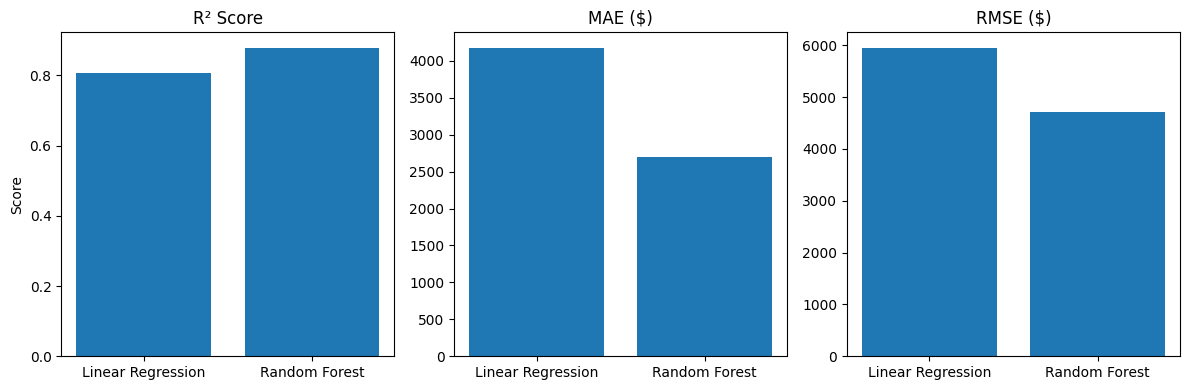

In [90]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Linear Regression', 'Random Forest']
r2_scores = [r2_lr, r2_rf]
mae_values = [mae_lr, mae_rf]
rmse_values = [rmse_lr, rmse_rf]

plt.figure(figsize=(12,4))

#   R2 Score
plt.subplot(1,3,1)
plt.bar(models, r2_scores)
plt.title("R² Score")
plt.ylabel("Score")

#   MAE
plt.subplot(1,3,2)
plt.bar(models, mae_values)
plt.title("MAE ($)")

#   RMSE
plt.subplot(1,3,3)
plt.bar(models, rmse_values)
plt.title("RMSE ($)")

plt.tight_layout()
plt.show()

## Sample Predictions

In [91]:
# Sample Data
sample_data = pd.DataFrame({
    'age': [25, 45, 55],
    'sex': [1, 0, 1],              # 1=Male, 0=Female
    'bmi': [22.0, 35.0, 28.5],
    'children': [0, 2, 3],
    'smoker': [0, 1, 0],           # 1=Smoker, 0=Non-Smoker
    'region_northwest': [0, 0, 1],
    'region_southeast': [1, 0, 0],
    'region_southwest': [0, 1, 0]
})

for col in X.columns:
    if col not in sample_data.columns:
        sample_data[col] = 0

sample_data = sample_data[X.columns]

# Predict using Random Forest 
predictions = lr.predict(sample_data)

# Display Results 
print("Sample Predictions using Random Forest")
print("="*39)

profiles = [
    "25-yr male, non-smoker, BMI 22",
    "45-yr female, SMOKER, BMI 35",
    "55-yr male, non-smoker, BMI 28.5"
]

for profile, pred in zip(profiles, predictions):
    print(f"{profile}")
    print(f"→ Predicted Charges: ${pred:,.0f}\n")

Sample Predictions using Random Forest
25-yr male, non-smoker, BMI 22
→ Predicted Charges: $1,158

45-yr female, SMOKER, BMI 35
→ Predicted Charges: $34,690

55-yr male, non-smoker, BMI 28.5
→ Predicted Charges: $12,807



In [92]:
# Sample Data
sample_data = pd.DataFrame({
    'age': [25, 45, 55],
    'sex': [1, 0, 1],              # 1=Male, 0=Female
    'bmi': [22.0, 35.0, 28.5],
    'children': [0, 2, 3],
    'smoker': [0, 1, 0],           # 1=Smoker, 0=Non-Smoker
    'region_northwest': [0, 0, 1],
    'region_southeast': [1, 0, 0],
    'region_southwest': [0, 1, 0]
})

for col in X.columns:
    if col not in sample_data.columns:
        sample_data[col] = 0

sample_data = sample_data[X.columns]

# Predict using Random Forest 
predictions = rf.predict(sample_data)

# Display Results 
print("Sample Predictions using Random Forest")
print("="*39)

profiles = [
    "25-yr male, non-smoker, BMI 22",
    "45-yr female, SMOKER, BMI 35",
    "55-yr male, non-smoker, BMI 28.5"
]

for profile, pred in zip(profiles, predictions):
    print(f"{profile}")
    print(f"→ Predicted Charges: ${pred:,.0f}\n")

Sample Predictions using Random Forest
25-yr male, non-smoker, BMI 22
→ Predicted Charges: $6,993

45-yr female, SMOKER, BMI 35
→ Predicted Charges: $42,525

55-yr male, non-smoker, BMI 28.5
→ Predicted Charges: $12,817



---
## Step 9: Results Explanation & Insights

### Key Findings

#### 1. Most Important Factor: Smoking
- Smokers have **much higher charges** than non-smokers  
- Smoking is the **main reason** for high medical costs  

---

#### 2. Age Effect
- As age increases → **charges also increase**  
- Older people need more healthcare  

---

#### 3. BMI Effect
- Higher BMI → **higher medical charges**  
- Especially risky when combined with smoking  

---

#### 4. Model Performance

| Model | R² Score | MAE | RMSE |
|------|---------|------|------|
| Linear Regression | 0.8072 | $4176.560 | $5951.121 |
| Random Forest | 0.8786 | $2697.545 | $4721.292 |


---

#### 5. Best Model: Random Forest
- Performs better than Linear Regression  
- Can handle **complex relationships** in data  
- Gives more accurate predictions  

---

###  Final Conclusion

- > Random Forest is the best model for predicting medical charges.  
- > Smoking, age, and BMI are the most important factors affecting cost.  
- > This model can help insurance companies estimate charges and make better decisions.

--- 
## Export the Cleaned Dataset

In [93]:
# Save the cleaned original dataset (before encoding)
df.to_csv('Insurance_Dataset_Clean.csv', index=False)

In [94]:
# Save the cleaned original dataset (after encoding)
df_model.to_csv('Insurance_Dataset_Clean_Encoded.csv', index=False)